In [25]:
import torch
import torch.nn as nn
import torchsde
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
import lightning as pl
import os
from dotenv import load_dotenv; load_dotenv()
%cd {os.getenv('PROJECT_PATH')}


from control.neuralsde import MLPSDE
from control.data import TimeSeriesDataset
from control.training import SDELightningModule, SDEWrapper
from control.contoller import StepController
from control.model import LinearControlSDE

/home/id94ebid/projects/neuroscience


In [26]:
batch_size = 128
num_workers = 1
state_size = 9
control_size = 2
wlen_train = 30
hidden_size = 32
hidden_layers = 1
lr = 5e-3
method = "euler"
dt = 1e-3

In [27]:
train_set = np.load("data_processed/control/train_laplace.npz")
test_set = np.load("data_processed/control/test_laplace.npz")
ts = train_set["t"]

train_dataset = TimeSeriesDataset(train_set, duplicate=100, window_length=wlen_train)
test_dataset = TimeSeriesDataset(test_set, window_length=200)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)    
val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

In [28]:
lighting = SDELightningModule(state_size, control_size, hidden_size, hidden_layers, controller_type='step', lr=lr, method=method, dt=dt)

checkpoint_callback = pl.pytorch.callbacks.ModelCheckpoint(monitor='val_loss', dirpath='checkpoints/', filename='sde-{epoch:02d}-{val_loss:.4f}', save_top_k=1, mode='min')
trainer = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    callbacks=[
        checkpoint_callback,
        pl.pytorch.callbacks.EarlyStopping(monitor='val_loss', patience=20, mode='min')
    ],
    logger=pl.pytorch.loggers.WandbLogger(project='sde_training', name='sde_run', save_dir='logs/'),
    #gradient_clip_val=10.0,
    log_every_n_steps=10
)   
trainer.fit(lighting, train_loader, val_loader)

# best_model_path = checkpoint_callback.best_model_path
# print(f"Best model saved at: {best_model_path}")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs
/home/id94ebid/projects/neuroscience/.venv/lib/python3.11/site-packages/lightning/pytorch/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
/home/id94ebid/projects/neuroscience/.venv/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /home/id94ebid/projects/neuroscience/checkpoints exists and is not empty.

  | Name        | Type       | Params | Mode 
---------------------------------------------------
0 | sde_wrapper | SDEWrapper | 1.7 K  | train
---------------------------------------------------
1.7 K     Trainable params
0         Non-trainable params
1.7 K     Total params
0.007     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/id94ebid/projects/neuroscience/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.
/home/id94ebid/projects/neuroscience/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


/home/id94ebid/projects/neuroscience/.venv/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=13` in the `DataLoader` to improve performance.


Epoch 9: 100%|██████████| 235/235 [01:19<00:00,  2.96it/s, v_num=spqn, train_loss=0.000272, lr=0.005, val_loss=0.020] 

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 235/235 [01:19<00:00,  2.96it/s, v_num=spqn, train_loss=0.000272, lr=0.005, val_loss=0.020]


In [29]:
x, u, ts = next(iter(val_loader))
x0 = x[:,0]
with torch.no_grad():
    ys = lighting(x0, ts, u).transpose(1,0)

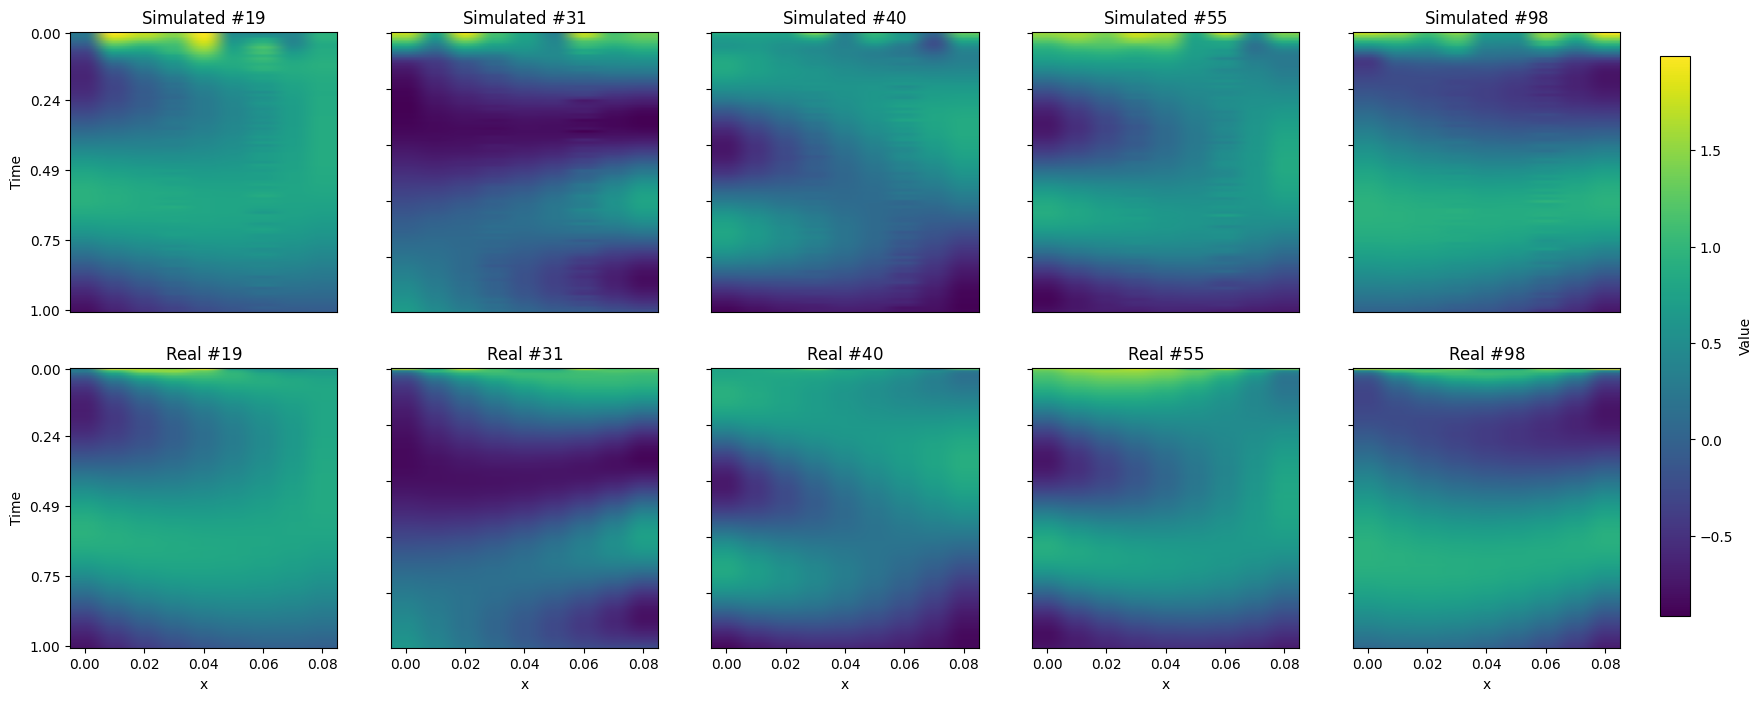

In [41]:
ts_np = ts[0].detach().numpy()
ys_np = ys.detach().numpy()
x_np = x.transpose(1,0).detach().numpy()

np.random.seed(42)
random_indices = np.random.choice(ys.shape[1], size=5, replace=False)
random_indices.sort()

num_plots = 5
fig, axes = plt.subplots(2, num_plots, figsize=(20, 8))

# Determine global min/max for consistent colormapping
# This is crucial for comparing the different timesteps
v_min = ys_np[:, random_indices, :].min()
v_max = ys_np[:, random_indices, :].max()

# Plot each matrix
for i, t_index in enumerate(random_indices):
    matrix = ys_np[:, t_index, :]
    # Use vmin and vmax for consistent colormapping
    im = axes[0,i].imshow(matrix, cmap='viridis', vmin=v_min, vmax=v_max, aspect='auto')
    axes[0,i].set_title(f'Simulated #${t_index}$')
    #axes[0,i].set_xlabel("x")
    axes[0,i].set_yticklabels([])
    tick_indices = np.linspace(0, ys_np.shape[-1]-1, 5, dtype=int)
    axes[0,i].set_xticks([])
    #axes[0,i].set_xticklabels([f'{ts_np[idx]:.2f}' for idx in tick_indices])

tick_indices = np.linspace(0, len(ts_np) - 1, 5, dtype=int)
axes[0,0].set_yticks(tick_indices)
axes[0,0].set_yticklabels([f'{ts_np[idx]:.2f}' for idx in tick_indices])

axes[0,0].set_ylabel("Time")



for i, t_index in enumerate(random_indices):
    matrix = x_np[:, t_index, :]
    # Use vmin and vmax for consistent colormapping
    im = axes[1,i].imshow(matrix, cmap='viridis', vmin=v_min, vmax=v_max, aspect='auto')
    axes[1,i].set_title(f'Real #${t_index}$')
    axes[1,i].set_xlabel("x")
    axes[1,i].set_yticklabels([])
    tick_indices = np.linspace(0, ys_np.shape[-1]-1, 5, dtype=int)
    axes[1,i].set_xticks(tick_indices)
    axes[1,i].set_xticklabels([f'{ts_np[idx]:.2f}' for idx in tick_indices])

tick_indices = np.linspace(0, len(ts_np) - 1, 5, dtype=int)
axes[1,0].set_yticks(tick_indices)
axes[1,0].set_yticklabels([f'{ts_np[idx]:.2f}' for idx in tick_indices])

axes[1,0].set_ylabel("Time")


# Add a single colorbar for all plots
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Value')

plt.savefig('images/training_laplace.png', dpi=300, bbox_inches='tight')
plt.show()